In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "lines.linewidth": 1.8,
    "lines.markersize": 4,
    "figure.dpi": 150
})

In [ ]:
files = {
    'fl-tpt': {
        'from_scratch': '../evaluation/results/fad_flute_trumpet_from_scratch_evaluation_general_clap.csv',
        'finetuned': '../evaluation/results/fad_flute_trumpet_evaluation_general_clap.csv',
    },
    'fl-vn': {
        'from_scratch': '../evaluation/results/fad_flute_violin_from_scratch_evaluation_general_clap.csv',
        'finetuned': '../evaluation/results/fad_flute_violin_evaluation_general_clap.csv',
    },
    'tpt-vn': {
        'from_scratch': '../evaluation/results/fad_trumpet_violin_from_scratch_evaluation_general_clap.csv',
        'finetuned': '../evaluation/results/fad_trumpet_violin_evaluation_general_clap.csv',
    },
}

def load(filename):
    df = pd.read_csv(filename)
    baseline = df.loc[df['category'].isna(), 'distance'].iloc[0]
    resynth = df.loc[df['category'] == 'resynthesis', 'distance'].iloc[0]
    weights_ext = df.loc[(df['category'] == 'weights') & (df['grouping'] == 'extremes'), 'distance'].iloc[0]
    weights_int = df.loc[(df['category'] == 'weights') & (df['grouping'] == 'unordered_pairs'), 'distance'].iloc[0]
    output_ext = df.loc[(df['category'] == 'output') & (df['grouping'] == 'extremes'), 'distance'].iloc[0]
    output_int = df.loc[(df['category'] == 'output') & (df['grouping'] == 'unordered_pairs'), 'distance'].iloc[0]
    return baseline, resynth, weights_ext, weights_int, output_ext, output_int

pairs = list(files.keys())
data = {}
for pair, models in files.items():
    b_s, r_s, we_s, wi_s, oe_s, oi_s = load(models['from_scratch'])
    b_f, r_f, we_f, wi_f, oe_f, oi_f = load(models['finetuned'])
    data[pair] = {
        'baseline': b_s,
        'scratch': [r_s, we_s, wi_s, oe_s, oi_s],
        'finetuned': [r_f, we_f, wi_f, oe_f, oi_f],
    }

bar_specs = [
    ('Resynthesis', '#2ca02c'),
    (r'Weights interpolation, $\alpha \in \{0, 1\}$', '#1f77b4'),
    (r'Weights interpolation, $\alpha \in \{0.25, 0.50, 0.75\}$', '#aec7e8'),
    (r'Parameters interpolation, $\alpha \in \{0, 1\}$', '#ff7f0e'),
    (r'Parameters interpolation, $\alpha \in \{0.25, 0.50, 0.75\}$', '#ffbb78'),
]

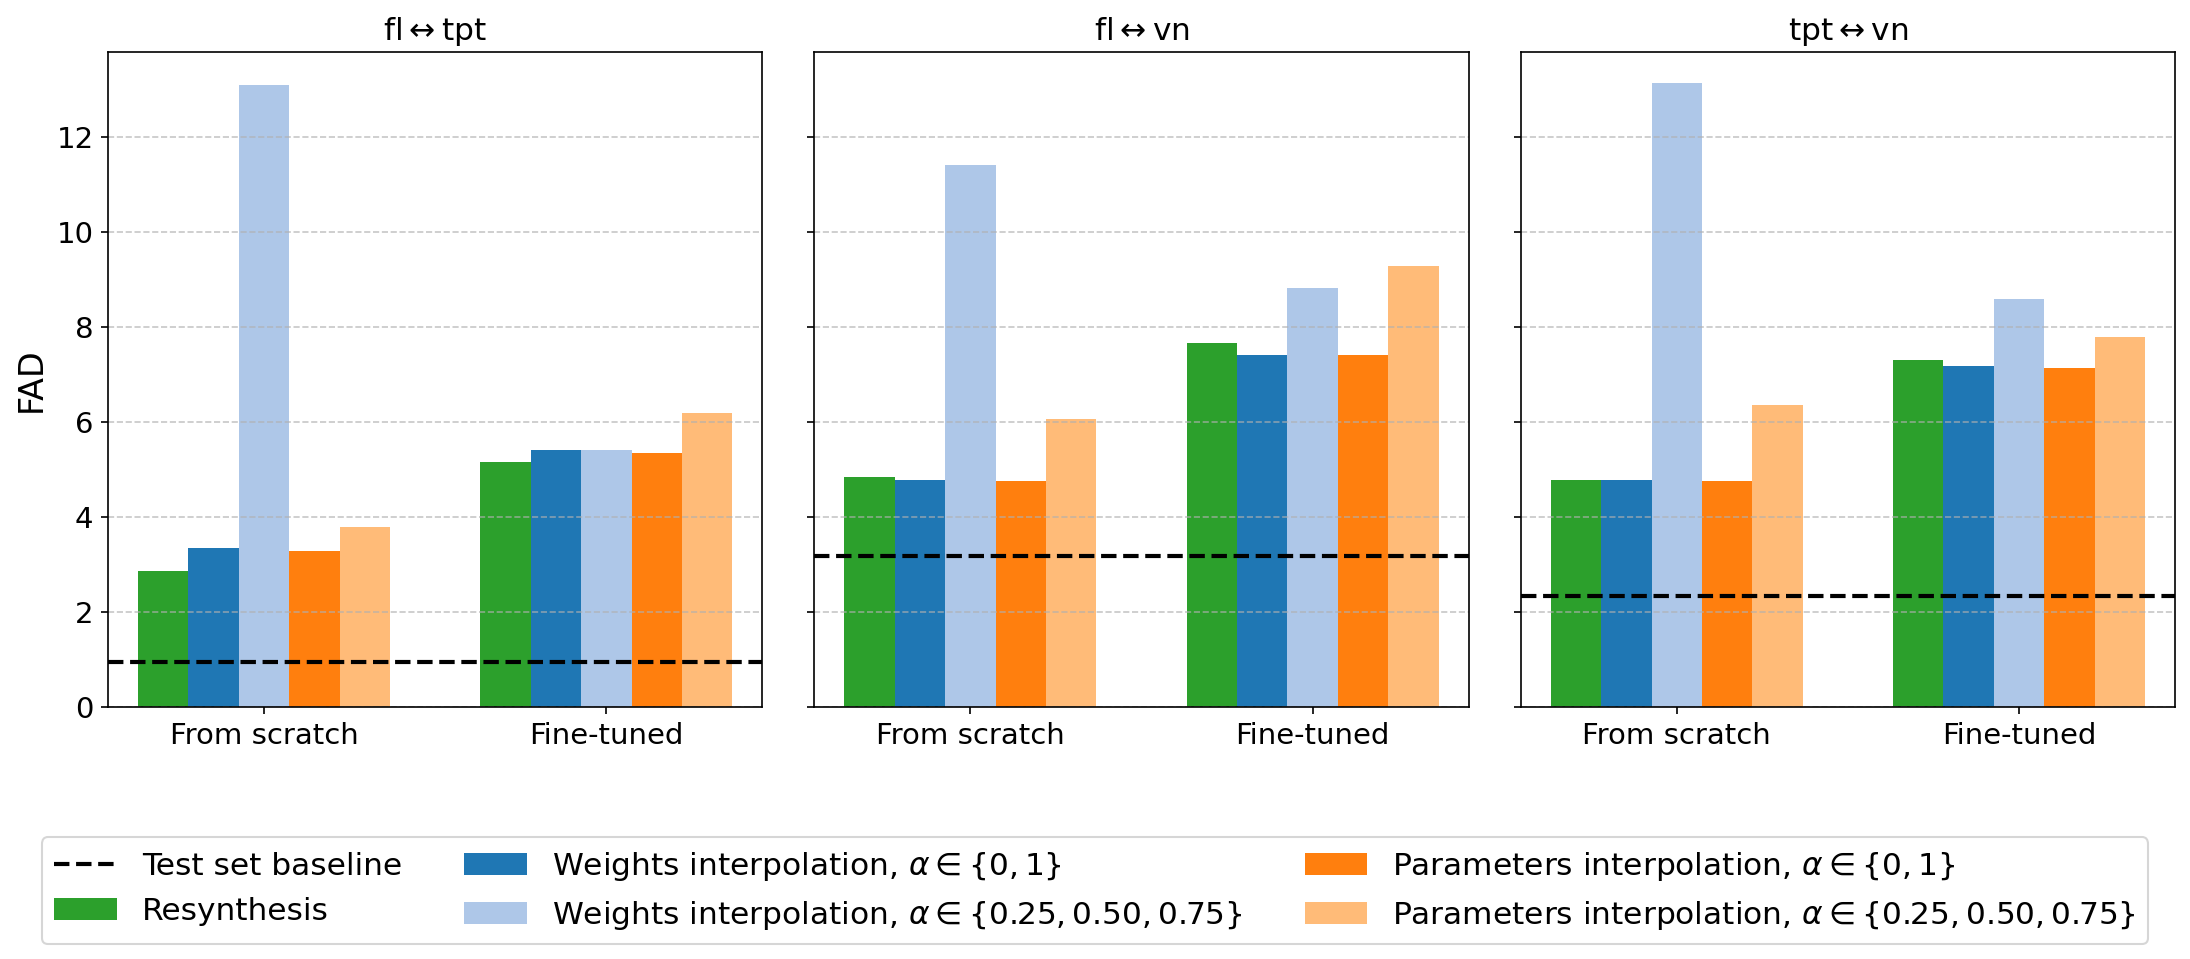

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)
width = 0.14
group_gap = 0.25

scratch_x = np.arange(len(bar_specs)) * width
finetuned_x = scratch_x + len(bar_specs) * width + group_gap

for ax, pair in zip(axes, pairs):
    d = data[pair]
    for i, (label, color) in enumerate(bar_specs):
        ax.bar(scratch_x[i], d['scratch'][i], width, color=color, linewidth=0.8,
               label=label if pair == pairs[0] else None)
        ax.bar(finetuned_x[i], d['finetuned'][i], width, color=color,linewidth=0.8)

    ax.axhline(d['baseline'], color='black', linestyle='--', linewidth=2.0,
               label='Test set baseline' if pair == pairs[0] else None)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    scratch_center = scratch_x.mean()
    finetuned_center = finetuned_x.mean()
    ax.set_xticks([scratch_center, finetuned_center])
    ax.set_xticklabels(['From scratch', 'Fine-tuned'])
    a, b = pair.split("-")
    ax.set_title(r"$\leftrightarrow$".join([a, b]), fontsize=15)

axes[0].set_ylabel('FAD')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2), fontsize=15)
fig.tight_layout()
plt.show()